# Interpretable and Explainable Machine Learning Models for Customer Churn Prediction in Subscription-Based Digital Services

### How do interpretable and black-box machine learning models compare in terms of predictive performance and explainability for customer churn prediction in subscription-based digital services?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!pip install lifelines

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from lifelines import KaplanMeierFitter
import shap

print('All libraries loaded.')


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ccf760e7c89d3078dbbc40e363c9794d986c9525cd46fd620014907e3c53a3e6
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
All libraries loaded.


## 1. Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/customer/dataset/dataset.csv'

df = pd.read_csv(file_path)
print('Shape:', df.shape)
display(df.head())

Mounted at /content/drive
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Inspection

In [3]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Dtypes:')
print(df.dtypes)
print('Missing values:')
print(df.isnull().sum())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Missing values:
customerID          0
g

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Data Preprocessing

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Missing after fix:', df.isnull().sum().sum())
print('Churn distribution:')
print(df['Churn'].value_counts())
print('Churn rate:', round(df['Churn'].mean() * 100, 2), '%')

Missing after fix: 0
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.54 %


## 4. Exploratory Data Analysis

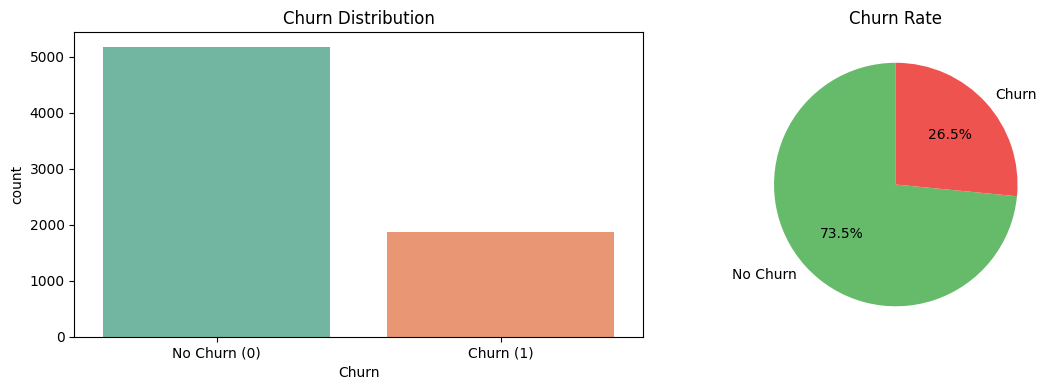

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])

churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#66bb6a', '#ef5350'], startangle=90)
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.show()

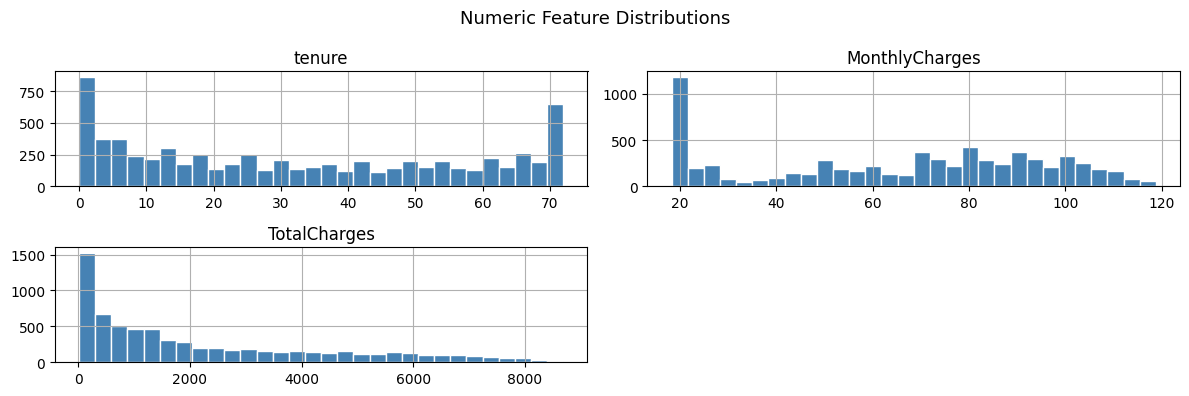

In [7]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(figsize=(12, 4), bins=30,
                                                        color='steelblue', edgecolor='white')
plt.suptitle('Numeric Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

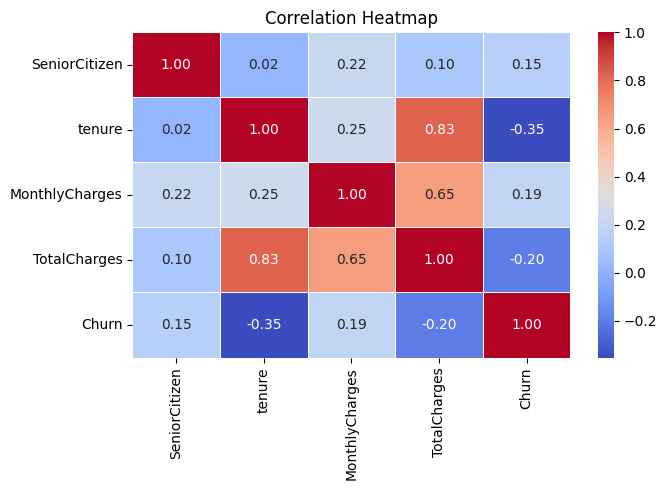

In [8]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 5. Time-Aware Feature Engineering




In [9]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

raw_accel = df['MonthlyCharges'] - df['AvgMonthlySpend']
df['ChargeAcceleration'] = raw_accel.clip(
    lower=raw_accel.quantile(0.01),
    upper=raw_accel.quantile(0.99)
)

df['TenureGroup'] = pd.cut(df['tenure'],
                            bins=[0, 6, 12, 24, 48, 72],
                            labels=['0-6m', '6-12m', '1-2yr', '2-4yr', '4-6yr'],
                            include_lowest=True)

contract_risk = {'Month-to-month': 3, 'One year': 2, 'Two year': 1}
df['ContractRisk'] = df['Contract'].map(contract_risk)

service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

df['ChargeGroup'] = pd.qcut(df['MonthlyCharges'], q=4,
                             labels=['Low', 'Medium', 'High', 'Premium'])

print('New engineered features:')
print(df[['AvgMonthlySpend', 'ChargeAcceleration', 'ContractRisk', 'ServiceCount']].describe())
print(f'\nChargeAcceleration clipped to [{df["ChargeAcceleration"].min():.2f}, {df["ChargeAcceleration"].max():.2f}]')


New engineered features:
       AvgMonthlySpend  ChargeAcceleration  ContractRisk  ServiceCount
count      7043.000000         7043.000000   7043.000000   7043.000000
mean         61.173413            5.668007      2.309527      2.941076
std          61.019723            8.676759      0.833755      1.843899
min           9.183333           -2.302837      1.000000      0.000000
25%          26.274411            0.756274      2.000000      1.000000
50%          61.150000            2.432857      3.000000      3.000000
75%          84.940047            6.379699      3.000000      4.000000
max        1397.475000           40.014500      3.000000      7.000000

ChargeAcceleration clipped to [-2.30, 40.01]


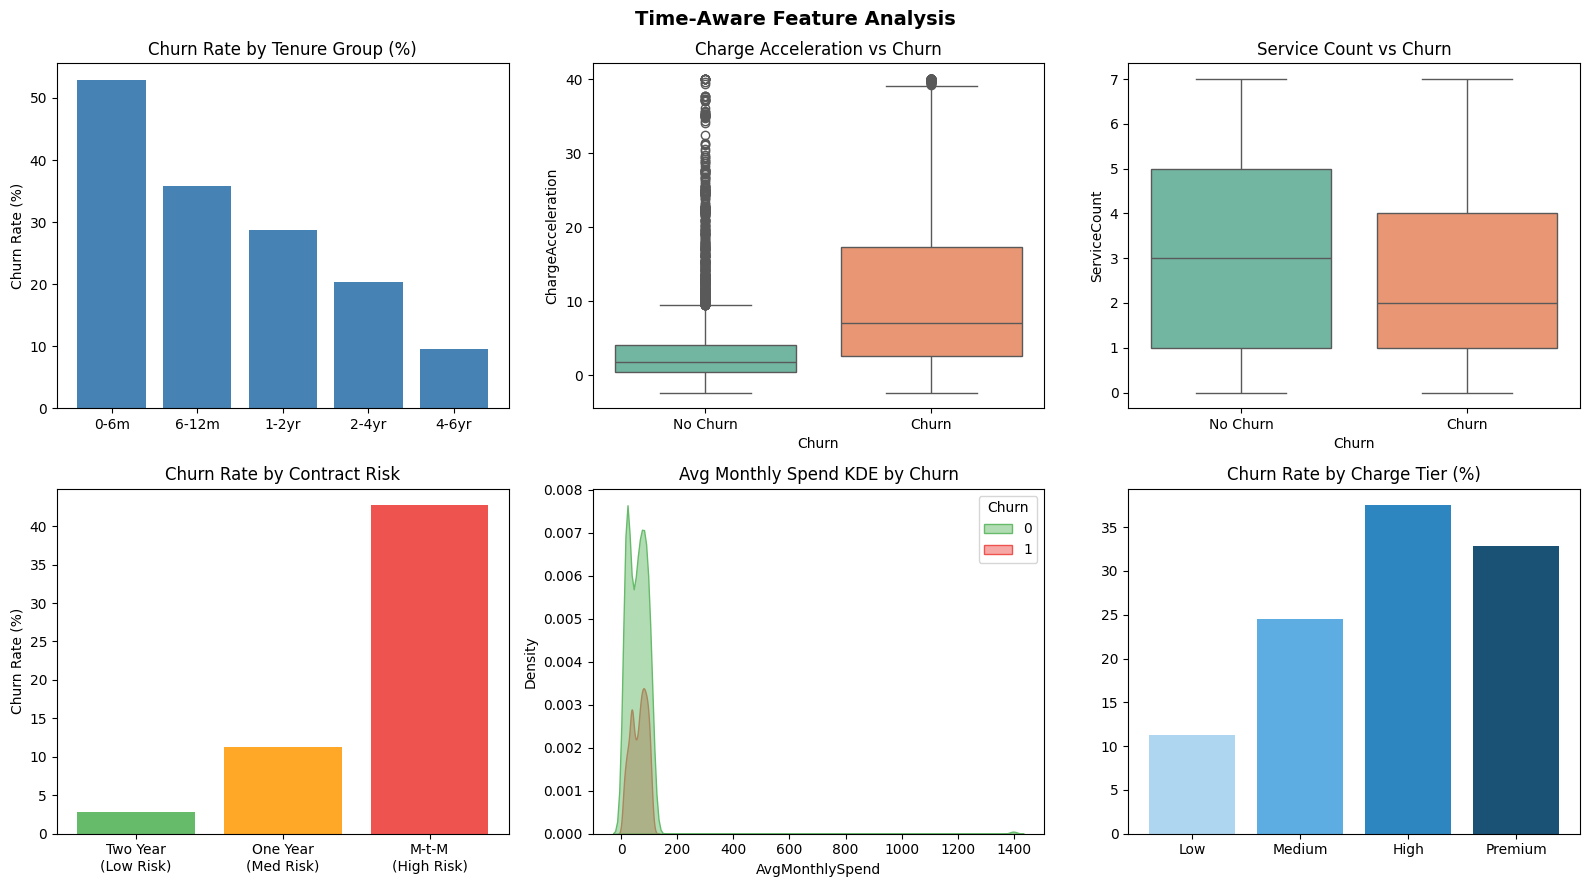

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))


churn_by_tenure = df.groupby('TenureGroup', observed=True)['Churn'].mean() * 100
axes[0,0].bar(churn_by_tenure.index, churn_by_tenure.values, color='steelblue')
axes[0,0].set_title('Churn Rate by Tenure Group (%)')
axes[0,0].set_ylabel('Churn Rate (%)')

sns.boxplot(x='Churn', y='ChargeAcceleration', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Charge Acceleration vs Churn')
axes[0,1].set_xticklabels(['No Churn', 'Churn'])

sns.boxplot(x='Churn', y='ServiceCount', data=df, ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Service Count vs Churn')
axes[0,2].set_xticklabels(['No Churn', 'Churn'])


churn_by_contract = df.groupby('ContractRisk')['Churn'].mean() * 100
axes[1,0].bar(['Two Year\n(Low Risk)', 'One Year\n(Med Risk)', 'M-t-M\n(High Risk)'],
              churn_by_contract.values, color=['#66bb6a', '#ffa726', '#ef5350'])
axes[1,0].set_title('Churn Rate by Contract Risk')
axes[1,0].set_ylabel('Churn Rate (%)')

sns.kdeplot(data=df, x='AvgMonthlySpend', hue='Churn', fill=True,
            alpha=0.5, ax=axes[1,1], palette={0: '#66bb6a', 1: '#ef5350'})
axes[1,1].set_title('Avg Monthly Spend KDE by Churn')


churn_by_charge = df.groupby('ChargeGroup', observed=True)['Churn'].mean() * 100
axes[1,2].bar(churn_by_charge.index, churn_by_charge.values,
              color=['#aed6f1', '#5dade2', '#2e86c1', '#1a5276'])
axes[1,2].set_title('Churn Rate by Charge Tier (%)')

plt.suptitle('Time-Aware Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Survival Analysis - Kaplan-Meier Estimator



Duration = tenure (months observed),  
Event = Churn (1 = churned, 0 = still active / censored)


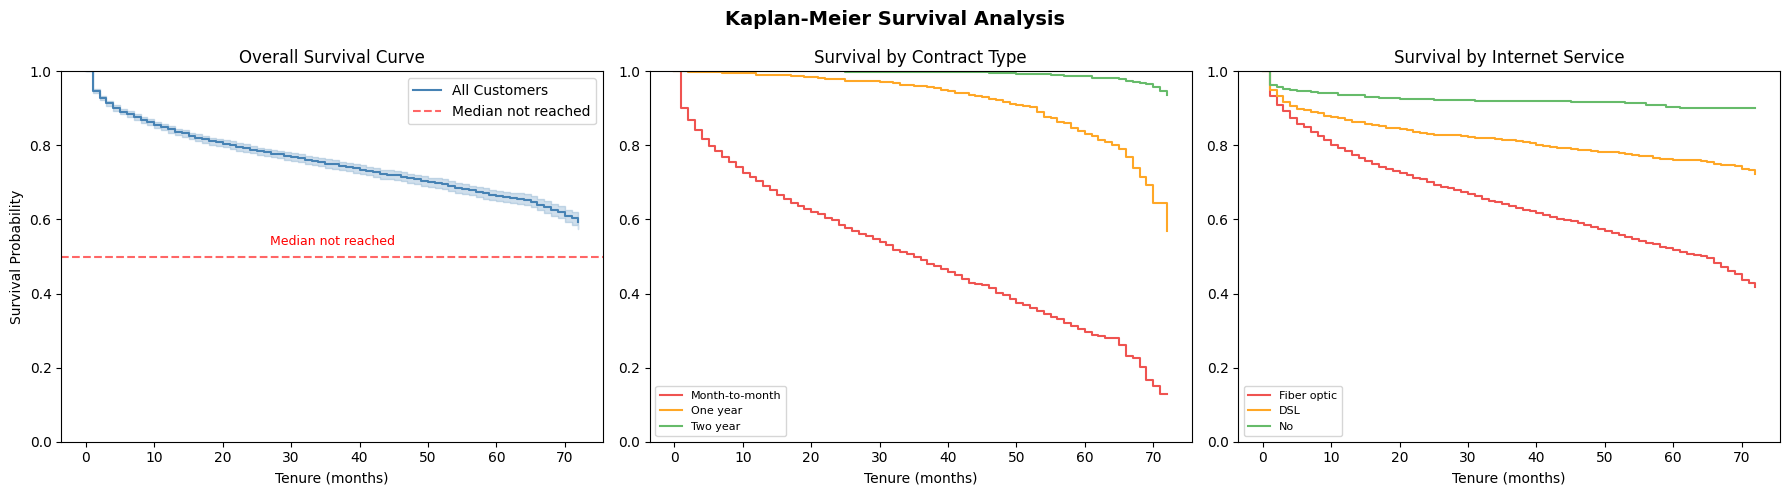

Overall median survival: Median not reached
Note: >50% of customers never churn by month 72 — median is not reached for the full cohort.
Month-to-month customers churn the fastest - contract is the #1 retention lever.


In [11]:
kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


kmf.fit(durations=df['tenure'], event_observed=df['Churn'], label='All Customers')
kmf.plot_survival_function(ax=axes[0], ci_show=True, color='steelblue')
median_surv = kmf.median_survival_time_
median_label = f'Median = {median_surv:.0f}m' if np.isfinite(median_surv) else 'Median not reached'
axes[0].set_title('Overall Survival Curve')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Survival Probability')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, linestyle='--', color='red', alpha=0.6, label=median_label)
axes[0].legend()
axes[0].text(0.5, 0.53, median_label, transform=axes[0].transAxes,
             ha='center', color='red', fontsize=9)


contract_colors = {'Month-to-month': '#ef5350', 'One year': '#ffa726', 'Two year': '#66bb6a'}
for contract, color in contract_colors.items():
    mask = df['Contract'] == contract
    kmf.fit(durations=df.loc[mask, 'tenure'],
            event_observed=df.loc[mask, 'Churn'], label=contract)
    kmf.plot_survival_function(ax=axes[1], ci_show=False, color=color)
axes[1].set_title('Survival by Contract Type')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)


internet_colors = {'Fiber optic': '#ef5350', 'DSL': '#ffa726', 'No': '#66bb6a'}
for itype, color in internet_colors.items():
    mask = df['InternetService'] == itype
    kmf.fit(durations=df.loc[mask, 'tenure'],
            event_observed=df.loc[mask, 'Churn'], label=itype)
    kmf.plot_survival_function(ax=axes[2], ci_show=False, color=color)
axes[2].set_title('Survival by Internet Service')
axes[2].set_xlabel('Tenure (months)')
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=8)

plt.suptitle('Kaplan-Meier Survival Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Overall median survival: {median_label}')
print('Note: >50% of customers never churn by month 72 — median is not reached for the full cohort.')
print('Month-to-month customers churn the fastest - contract is the #1 retention lever.')

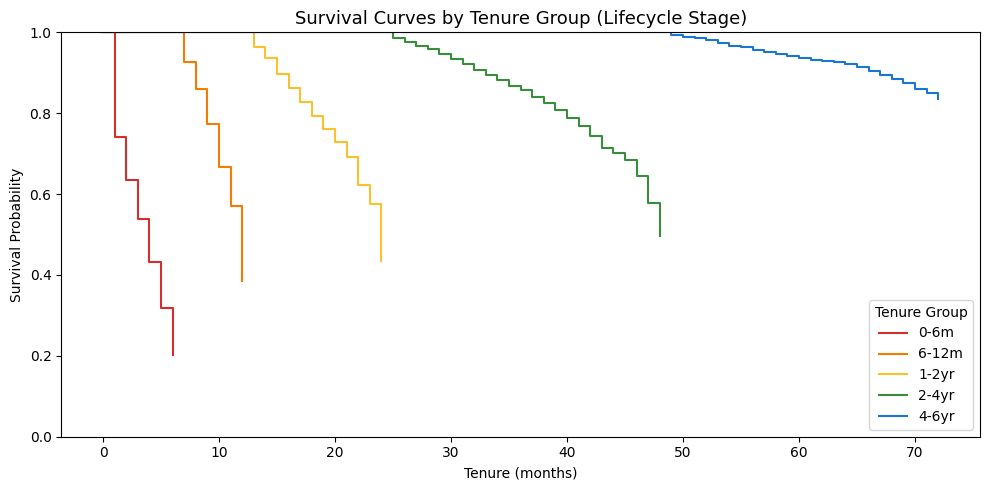

In [12]:
kmf2 = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 5))

tenure_colors = {'0-6m': '#d32f2f', '6-12m': '#f57c00', '1-2yr': '#fbc02d',
                 '2-4yr': '#388e3c', '4-6yr': '#1976d2'}

for group, color in tenure_colors.items():
    mask = df['TenureGroup'] == group
    if mask.sum() < 10:
        continue
    kmf2.fit(durations=df.loc[mask, 'tenure'],
             event_observed=df.loc[mask, 'Churn'], label=group)
    kmf2.plot_survival_function(ax=ax, ci_show=False, color=color)

ax.set_title('Survival Curves by Tenure Group (Lifecycle Stage)', fontsize=13)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1)
ax.legend(title='Tenure Group')
plt.tight_layout()
plt.show()

## 7. Feature Preparation for Predictive Modelling

In [13]:
df_ml = df.copy()

cols_to_drop = ['customerID', 'TenureGroup', 'ChargeGroup']
df_ml = df_ml.drop(columns=[c for c in cols_to_drop if c in df_ml.columns])

X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

X = pd.get_dummies(X, drop_first=True)

print('Feature matrix shape:', X.shape)
print('Features:', X.columns.tolist())

Feature matrix shape: (7043, 34)
Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'ChargeAcceleration', 'ContractRisk', 'ServiceCount', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [14]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Train (after SMOTE): {X_train_sm.shape}')
print(f'Test: {X_test.shape}')
print(f'SMOTE balance: {dict(pd.Series(y_train_sm).value_counts())}')

Train (after SMOTE): (8278, 34)
Test: (1409, 34)
SMOTE balance: {0: np.int64(4139), 1: np.int64(4139)}


## 8. Model Training - Black-Box vs Interpretable


In [15]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train_sm, y_train_sm)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]


rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf_default = rf.predict(X_test)
y_prob_rf_default = rf.predict_proba(X_test)[:, 1]

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train_sm, y_train_sm)
y_pred_xgb_default = xgb_model.predict(X_test)
y_prob_xgb_default = xgb_model.predict_proba(X_test)[:, 1]

print('All base models trained.')
print('LR  AUC:', round(roc_auc_score(y_test, y_prob_lr), 4))
print('DT  AUC:', round(roc_auc_score(y_test, y_prob_dt), 4))
print('RF  AUC:', round(roc_auc_score(y_test, y_prob_rf_default), 4))
print('XGB AUC:', round(roc_auc_score(y_test, y_prob_xgb_default), 4))

All base models trained.
LR  AUC: 0.8457
DT  AUC: 0.823
RF  AUC: 0.8286
XGB AUC: 0.8269


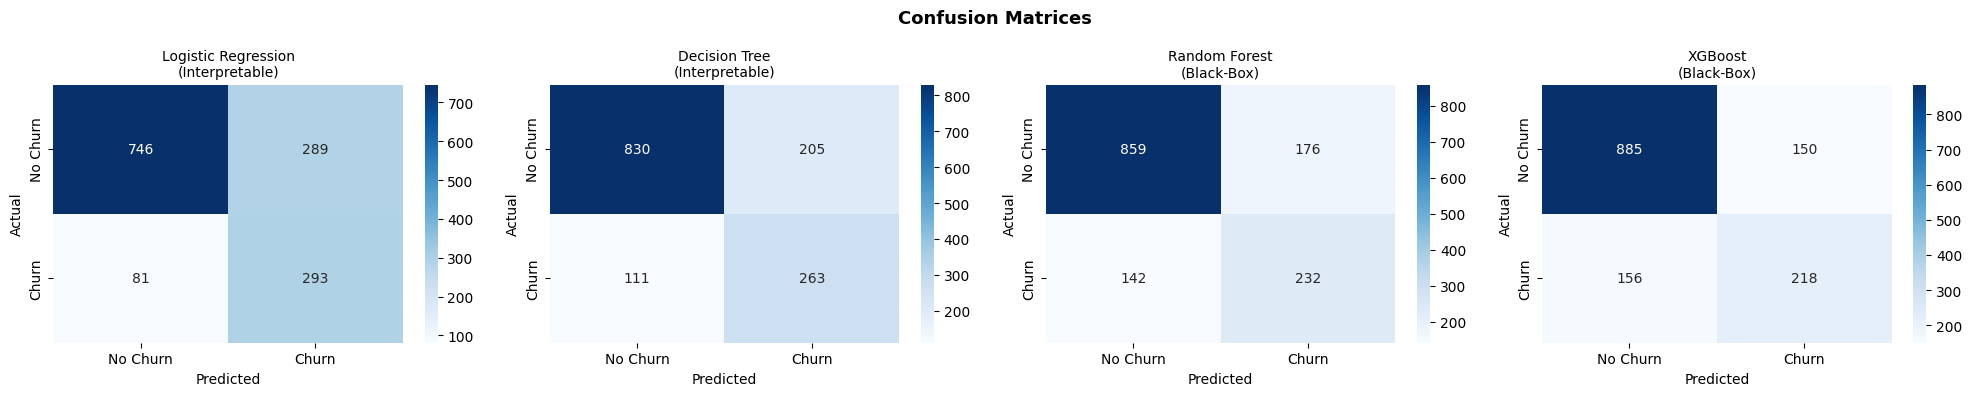

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

models_cms = [
    ('Logistic Regression\n(Interpretable)', y_pred_lr),
    ('Decision Tree\n(Interpretable)', y_pred_dt),
    ('Random Forest\n(Black-Box)', y_pred_rf_default),
    ('XGBoost\n(Black-Box)', y_pred_xgb_default),
]

for ax, (title, preds) in zip(axes, models_cms):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning

In [17]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=3, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train_sm, y_train_sm)
rf_best = rf_grid.best_estimator_

y_pred_rf_tuned = rf_best.predict(X_test)
y_prob_rf_tuned = rf_best.predict_proba(X_test)[:, 1]

print('Best RF params:', rf_grid.best_params_)
print('Tuned RF AUC:  ', round(roc_auc_score(y_test, y_prob_rf_tuned), 4))

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Tuned RF AUC:   0.8295


In [18]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    xgb_params, cv=3, scoring='roc_auc', n_jobs=-1
)
xgb_grid.fit(X_train_sm, y_train_sm)
xgb_best = xgb_grid.best_estimator_

y_pred_xgb_tuned = xgb_best.predict(X_test)
y_prob_xgb_tuned = xgb_best.predict_proba(X_test)[:, 1]

print('Best XGB params:', xgb_grid.best_params_)
print('Tuned XGB AUC:  ', round(roc_auc_score(y_test, y_prob_xgb_tuned), 4))

Best XGB params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Tuned XGB AUC:   0.8212


In [19]:
rf_final = rf_best if roc_auc_score(y_test, y_prob_rf_tuned) >= roc_auc_score(y_test, y_prob_rf_default) else rf
y_pred_rf_final = rf_final.predict(X_test)
y_prob_rf_final = rf_final.predict_proba(X_test)[:, 1]

xgb_final = xgb_best if roc_auc_score(y_test, y_prob_xgb_tuned) >= roc_auc_score(y_test, y_prob_xgb_default) else xgb_model
y_pred_xgb_final = xgb_final.predict(X_test)
y_prob_xgb_final = xgb_final.predict_proba(X_test)[:, 1]

print('Final RF  AUC:', round(roc_auc_score(y_test, y_prob_rf_final), 4))
print('Final XGB AUC:', round(roc_auc_score(y_test, y_prob_xgb_final), 4))

Final RF  AUC: 0.8295
Final XGB AUC: 0.8269


## 10. Full Comparison - Predictive Power vs Explainability

In [20]:
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4),
    }

results = {
    'Logistic Regression (Interpretable)': get_metrics(y_test, y_pred_lr, y_prob_lr),
    'Decision Tree (Interpretable)':       get_metrics(y_test, y_pred_dt, y_prob_dt),
    'Random Forest (Black-Box)':           get_metrics(y_test, y_pred_rf_final, y_prob_rf_final),
    'XGBoost (Black-Box)':                 get_metrics(y_test, y_pred_xgb_final, y_prob_xgb_final),
}

comparison_df = pd.DataFrame(results).T
comparison_df.index.name = 'Model'
comparison_df['Explainability (1-5)'] = [5, 4, 2, 2]
comparison_df['Category'] = ['Interpretable', 'Interpretable', 'Black-Box', 'Black-Box']

best_model = comparison_df['AUC-ROC'].idxmax()
best_auc   = comparison_df['AUC-ROC'].max()
print(f'Best model by AUC-ROC: {best_model} ({best_auc:.4f})')
print()
print(comparison_df.to_string())

lr_auc  = comparison_df.loc['Logistic Regression (Interpretable)', 'AUC-ROC']
bb_best = comparison_df[comparison_df['Category']=='Black-Box']['AUC-ROC'].max()
if lr_auc >= bb_best:
    print(f'\nNOTE: Logistic Regression (AUC={lr_auc:.4f}) matches or outperforms black-box models (best BB AUC={bb_best:.4f}).')
    print('This is common on tabular churn data with SMOTE balancing — interpretability comes at no cost here.')
else:
    print(f'\nNOTE: Black-box models outperform LR by {(bb_best - lr_auc)*100:.1f}pp AUC.')

Best model by AUC-ROC: Logistic Regression (Interpretable) (0.8457)

                                     Accuracy  Precision  Recall  F1 Score  AUC-ROC  Explainability (1-5)       Category
Model                                                                                                                   
Logistic Regression (Interpretable)    0.7374     0.5034  0.7834    0.6130   0.8457                     5  Interpretable
Decision Tree (Interpretable)          0.7757     0.5620  0.7032    0.6247   0.8230                     4  Interpretable
Random Forest (Black-Box)              0.7736     0.5669  0.6230    0.5936   0.8295                     2      Black-Box
XGBoost (Black-Box)                    0.7828     0.5924  0.5829    0.5876   0.8269                     2      Black-Box

NOTE: Logistic Regression (AUC=0.8457) matches or outperforms black-box models (best BB AUC=0.8295).
This is common on tabular churn data with SMOTE balancing — interpretability comes at no cost here.


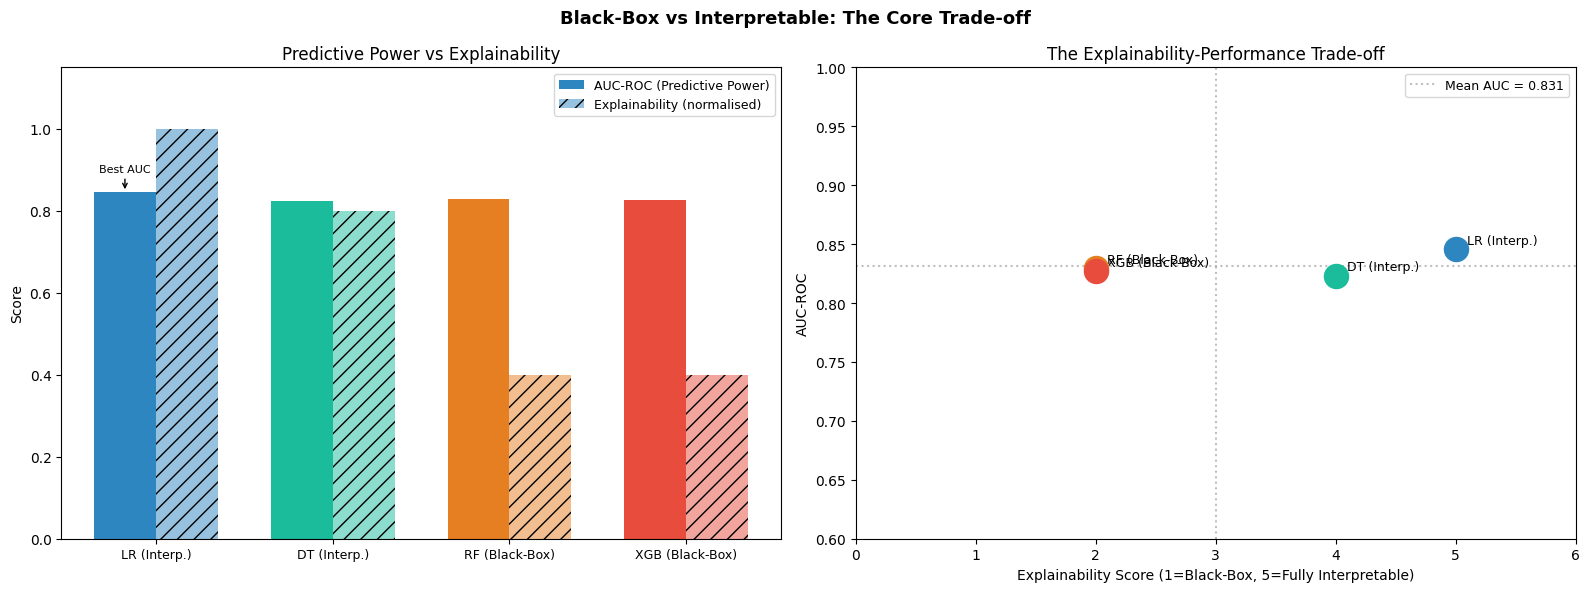

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_labels = ['LR (Interp.)', 'DT (Interp.)', 'RF (Black-Box)', 'XGB (Black-Box)']
aucs = comparison_df['AUC-ROC'].values
explainabilities = comparison_df['Explainability (1-5)'].values / 5
cat_colors = ['#2e86c1', '#1abc9c', '#e67e22', '#e74c3c']

x = np.arange(len(model_labels))
w = 0.35
axes[0].bar(x - w/2, aucs, w, label='AUC-ROC (Predictive Power)', color=cat_colors)
axes[0].bar(x + w/2, explainabilities, w, label='Explainability (normalised)',
            color=cat_colors, alpha=0.5, hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('Predictive Power vs Explainability')
axes[0].legend(fontsize=9)

best_idx = np.argmax(aucs)
axes[0].annotate('Best AUC', xy=(x[best_idx] - w/2, aucs[best_idx]),
                 xytext=(x[best_idx] - w/2, aucs[best_idx] + 0.05),
                 ha='center', fontsize=8, color='black',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1))

for i, (model, row) in enumerate(comparison_df.iterrows()):
    axes[1].scatter(row['Explainability (1-5)'], row['AUC-ROC'],
                   s=300, color=cat_colors[i], zorder=5)
    axes[1].annotate(model_labels[i],
                    (row['Explainability (1-5)'], row['AUC-ROC']),
                    textcoords='offset points', xytext=(8, 4), fontsize=9)

axes[1].set_xlabel('Explainability Score (1=Black-Box, 5=Fully Interpretable)')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('The Explainability-Performance Trade-off')
axes[1].set_xlim(0, 6)
axes[1].set_ylim(0.6, 1.0)
axes[1].axvline(3, linestyle=':', color='gray', alpha=0.5)
axes[1].axhline(comparison_df['AUC-ROC'].mean(), linestyle=':', color='gray', alpha=0.5,
                label=f'Mean AUC = {comparison_df["AUC-ROC"].mean():.3f}')
axes[1].legend(fontsize=9)

plt.suptitle('Black-Box vs Interpretable: The Core Trade-off', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

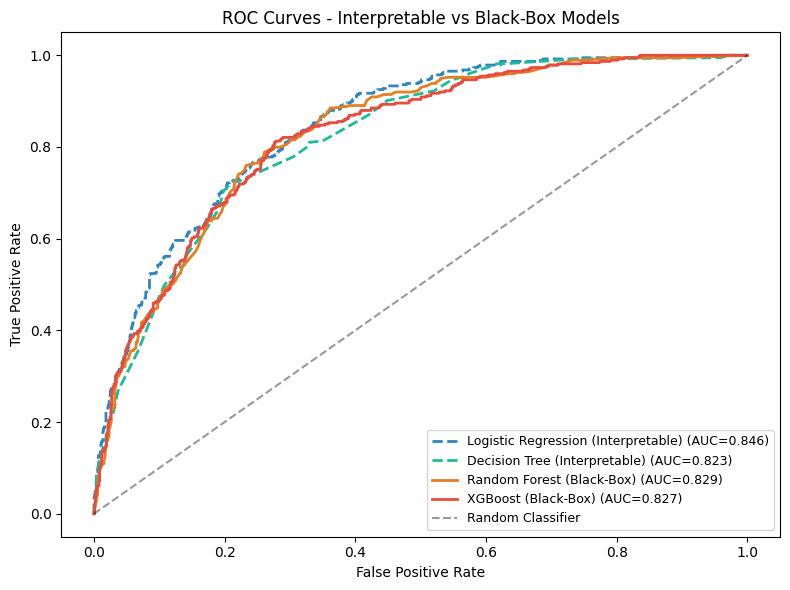

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

roc_models = [
    ('Logistic Regression (Interpretable)', y_prob_lr, '#2e86c1', '--'),
    ('Decision Tree (Interpretable)', y_prob_dt, '#1abc9c', '--'),
    ('Random Forest (Black-Box)', y_prob_rf_final, '#e67e22', '-'),
    ('XGBoost (Black-Box)', y_prob_xgb_final, '#e74c3c', '-'),
]

for name, prob, color, ls in roc_models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
            color=color, linestyle=ls, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Interpretable vs Black-Box Models', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## 11. Cross-Validation with SMOTE Pipeline (No Leakage)



In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_pipeline_auc(estimator):
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', estimator)
    ])
    return cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('Running 5-fold CV with SMOTE inside pipeline...')
cv_lr  = cv_pipeline_auc(LogisticRegression(max_iter=1000, random_state=42))
cv_dt  = cv_pipeline_auc(DecisionTreeClassifier(max_depth=6, random_state=42))
cv_rf  = cv_pipeline_auc(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
cv_xgb = cv_pipeline_auc(XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1))

cv_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Category': ['Interpretable', 'Interpretable', 'Black-Box', 'Black-Box'],
    'CV AUC Mean': [cv_lr.mean(), cv_dt.mean(), cv_rf.mean(), cv_xgb.mean()],
    'CV AUC Std':  [cv_lr.std(),  cv_dt.std(),  cv_rf.std(),  cv_xgb.std()],
})

print(cv_results.round(4).to_string(index=False))

Running 5-fold CV with SMOTE inside pipeline...
              Model      Category  CV AUC Mean  CV AUC Std
Logistic Regression Interpretable       0.8411      0.0095
      Decision Tree Interpretable       0.8097      0.0069
      Random Forest     Black-Box       0.8248      0.0075
            XGBoost     Black-Box       0.8167      0.0121


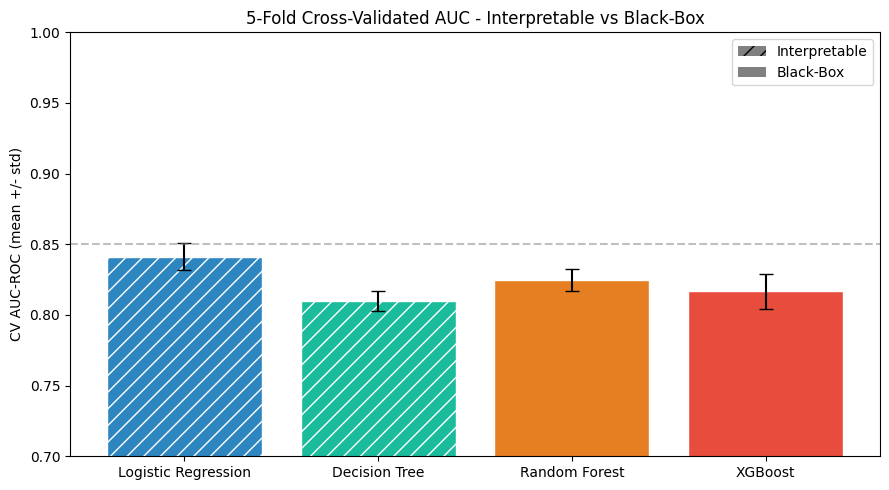

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
cv_colors = ['#2e86c1', '#1abc9c', '#e67e22', '#e74c3c']
bars = ax.bar(cv_results['Model'], cv_results['CV AUC Mean'],
              yerr=cv_results['CV AUC Std'], capsize=5,
              color=cv_colors, edgecolor='white')

for bar, cat in zip(bars, cv_results['Category']):
    if cat == 'Interpretable':
        bar.set_hatch('//')

ax.set_ylabel('CV AUC-ROC (mean +/- std)')
ax.set_title('5-Fold Cross-Validated AUC - Interpretable vs Black-Box', fontsize=12)
ax.set_ylim(0.7, 1.0)
ax.axhline(0.85, linestyle='--', color='gray', alpha=0.5, label='AUC=0.85 reference')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='gray', hatch='//', label='Interpretable'),
              Patch(facecolor='gray', label='Black-Box')]
ax.legend(handles=legend_els)
plt.tight_layout()
plt.show()

## 12. Interpretable Insights - Logistic Regression Coefficients

In [25]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Coefficient', ascending=False)

print('TOP 10 FEATURES INCREASING CHURN RISK ')
print(coef_df.head(10).to_string(index=False))
print('\n TOP 10 FEATURES REDUCING CHURN RISK ')
print(coef_df.tail(10).sort_values('Coefficient').to_string(index=False))

TOP 10 FEATURES INCREASING CHURN RISK 
                       Feature  Coefficient  Odds Ratio
   InternetService_Fiber optic     0.876869    2.403362
                  TotalCharges     0.656203    1.927460
                  ContractRisk     0.396700    1.486910
           StreamingMovies_Yes     0.345031    1.412034
               StreamingTV_Yes     0.277818    1.320246
             MultipleLines_Yes     0.276008    1.317858
            ChargeAcceleration     0.242926    1.274974
          PaperlessBilling_Yes     0.219340    1.245255
PaymentMethod_Electronic check     0.172927    1.188779
                  ServiceCount     0.108401    1.114494

 TOP 10 FEATURES REDUCING CHURN RISK 
                             Feature  Coefficient  Odds Ratio
                              tenure    -1.020122    0.360551
                      MonthlyCharges    -0.995902    0.369390
                     AvgMonthlySpend    -0.717855    0.487797
                   Contract_Two year    -0.317853    0.727

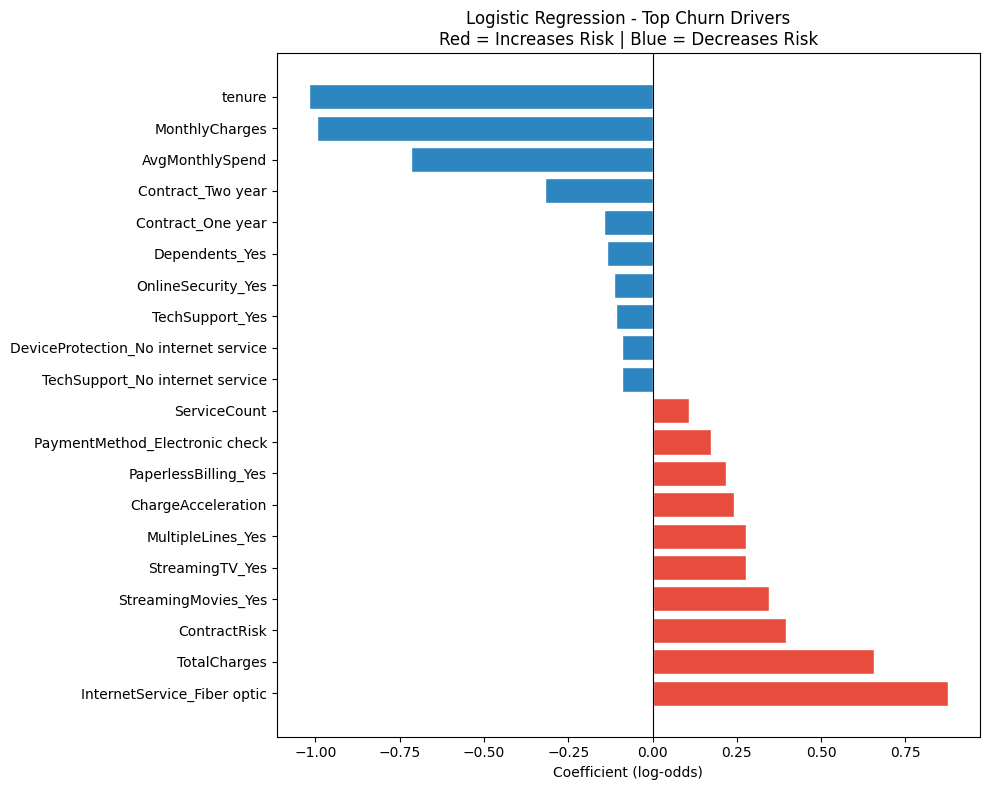

In [26]:
top_n = 20
coef_plot = pd.concat([coef_df.head(top_n//2), coef_df.tail(top_n//2)])

fig, ax = plt.subplots(figsize=(10, 8))
colors_coef = ['#e74c3c' if c > 0 else '#2e86c1' for c in coef_plot['Coefficient']]
ax.barh(coef_plot['Feature'], coef_plot['Coefficient'], color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Logistic Regression - Top Churn Drivers\nRed = Increases Risk | Blue = Decreases Risk', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Interpretable Insights - Decision Tree Feature Importances

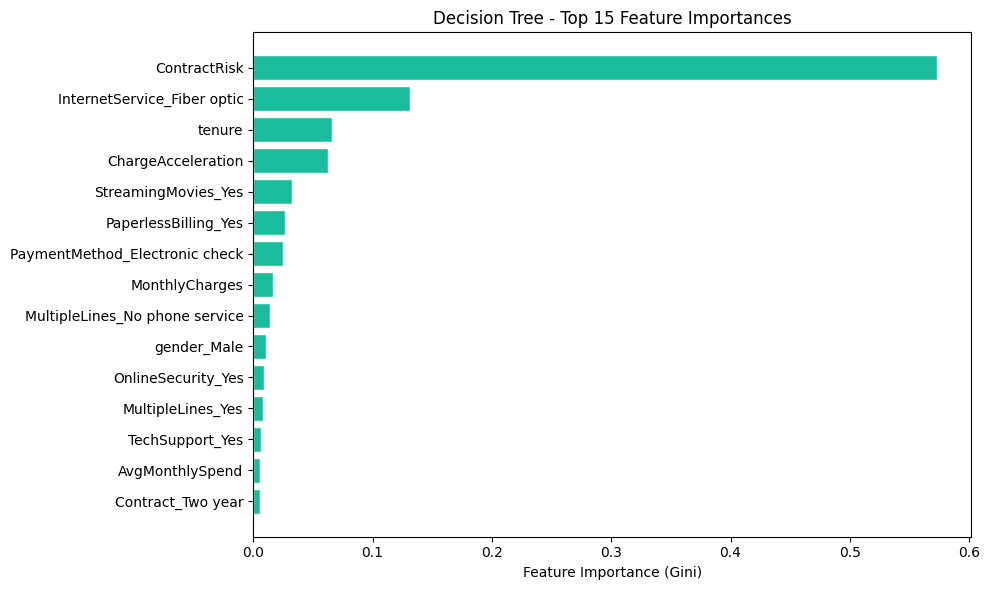

In [27]:
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(dt_importance['Feature'][::-1], dt_importance['Importance'][::-1],
        color='#1abc9c', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree - Top 15 Feature Importances', fontsize=12)
plt.tight_layout()
plt.show()

## 14. SHAP - Opening the Black Boxes




In [28]:
explainer_xgb = shap.Explainer(xgb_final, X_train)
shap_values_xgb = explainer_xgb(X_test)

explainer_rf = shap.TreeExplainer(rf_final)
shap_values_rf = explainer_rf(X_test)

print('SHAP values computed.')

 94%|=================== | 1331/1409 [00:13<00:00]       

SHAP values computed.


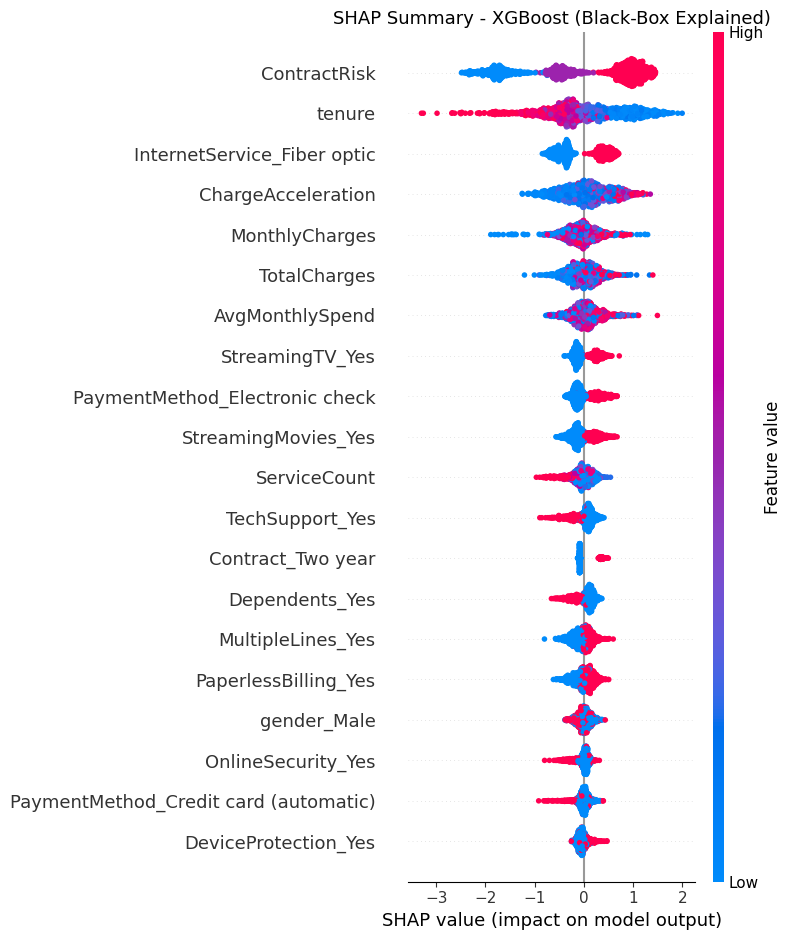

In [29]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.title('SHAP Summary - XGBoost (Black-Box Explained)', fontsize=13)
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

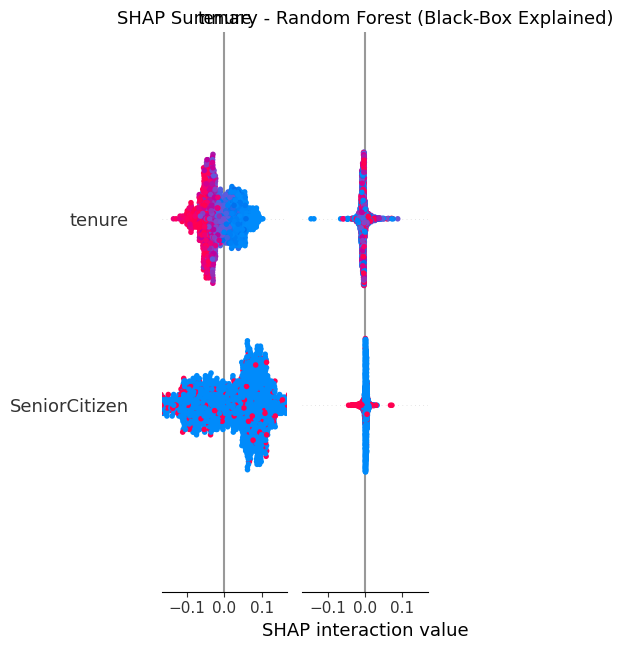

In [30]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rf, X_test, show=False)
plt.title('SHAP Summary - Random Forest (Black-Box Explained)', fontsize=13)
plt.tight_layout()
plt.show()

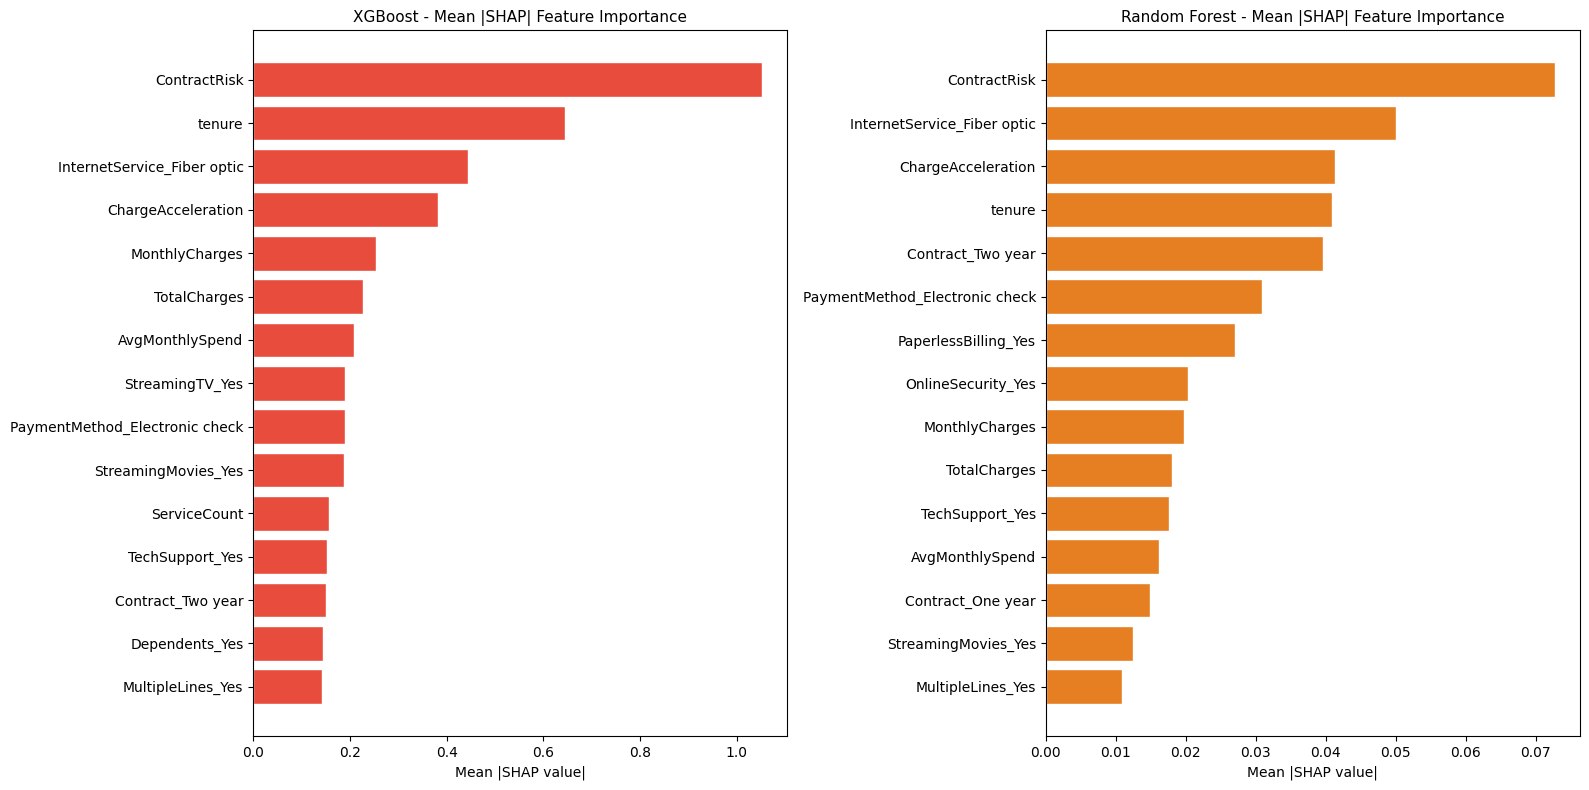

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

xgb_vals = shap_values_xgb.values
if xgb_vals.ndim == 3:
    xgb_vals = xgb_vals[:, :, 1]
xgb_mean_shap = np.abs(xgb_vals).mean(axis=0)
xgb_feat_imp = pd.Series(xgb_mean_shap, index=X_test.columns).sort_values(ascending=True).tail(15)
axes[0].barh(xgb_feat_imp.index, xgb_feat_imp.values, color='#e74c3c', edgecolor='white')
axes[0].set_title('XGBoost - Mean |SHAP| Feature Importance', fontsize=11)
axes[0].set_xlabel('Mean |SHAP value|')


rf_vals = shap_values_rf.values
if rf_vals.ndim == 3:
    rf_vals = rf_vals[:, :, 1]
rf_mean_shap = np.abs(rf_vals).mean(axis=0)
rf_feat_imp = pd.Series(rf_mean_shap, index=X_test.columns).sort_values(ascending=True).tail(15)
axes[1].barh(rf_feat_imp.index, rf_feat_imp.values, color='#e67e22', edgecolor='white')
axes[1].set_title('Random Forest - Mean |SHAP| Feature Importance', fontsize=11)
axes[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.show()

Explaining customer at index 618
Predicted churn probability: 99.05%
Actual churn: 1


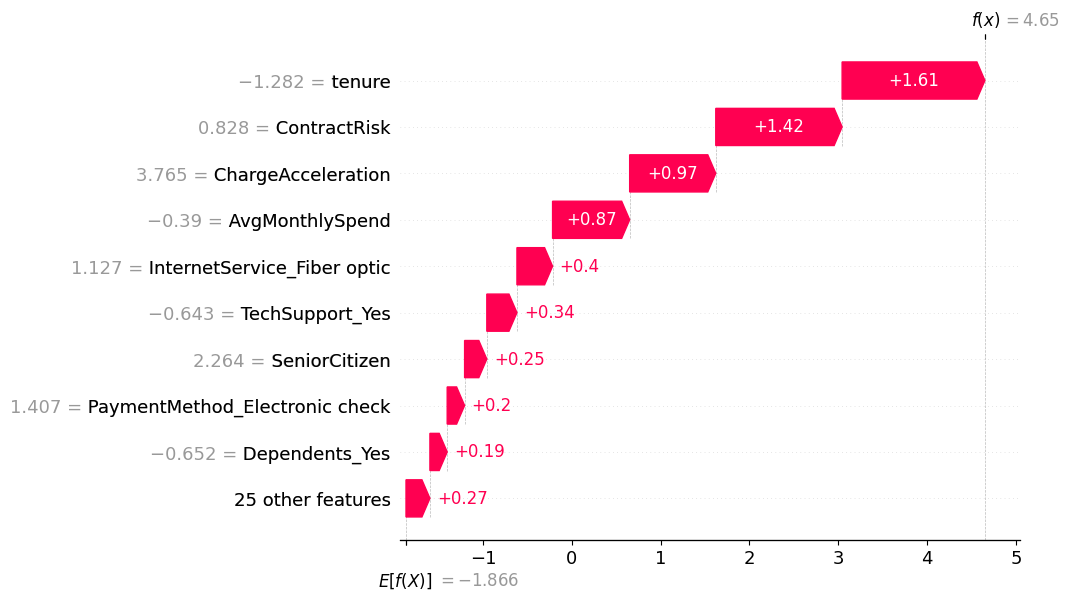

In [32]:
high_risk_idx = int(np.argmax(y_prob_xgb_final))
print(f'Explaining customer at index {high_risk_idx}')
print(f'Predicted churn probability: {y_prob_xgb_final[high_risk_idx]:.2%}')
print(f'Actual churn: {y_test.iloc[high_risk_idx]}')
shap.plots.waterfall(shap_values_xgb[high_risk_idx])

## 15. Final Summary & Business Recommendations

In [34]:
print('FINAL MODEL PERFORMANCE')
print(comparison_df[['Category', 'Accuracy', 'Recall', 'F1 Score', 'AUC-ROC', 'Explainability (1-5)']].to_string())

best_model_name = comparison_df['AUC-ROC'].idxmax()
best_auc_val    = comparison_df['AUC-ROC'].max()
lr_auc_val      = comparison_df.loc['Logistic Regression (Interpretable)', 'AUC-ROC']
bb_best_val     = comparison_df[comparison_df['Category'] == 'Black-Box']['AUC-ROC'].max()
power_note = (
    f'Logistic Regression matches/outperforms black-box models (LR AUC={lr_auc_val:.4f} >= BB AUC={bb_best_val:.4f}).\n'
    '  With SMOTE + proper scaling, interpretable models can be equally powerful.'
    if lr_auc_val >= bb_best_val else
    f'Black-box models outperform LR by {(bb_best_val - lr_auc_val)*100:.1f}pp AUC.'
)

print(f'''

KEY FINDINGS
1. PREDICTIVE POWER:
   Best model: {best_model_name} (AUC={best_auc_val:.4f})
   {power_note}

2. EXPLAINABILITY:
   LR coefficients give direct odds ratios per feature.
   SHAP closes the gap for black-box — best of both worlds.

3. SURVIVAL ANALYSIS (Kaplan-Meier):
   Median survival not reached — most customers survive to month 72.
   Month-to-month contracts drive 3x higher early churn hazard.
   First 6 months are the critical window for retention intervention.

RECOMMENDATIONS

- Prioritise Month-to-month customers in months 1-6 with contract
  upgrade offers — highest hazard, highest retention potential.

''')


FINAL MODEL PERFORMANCE
                                          Category  Accuracy  Recall  F1 Score  AUC-ROC  Explainability (1-5)
Model                                                                                                        
Logistic Regression (Interpretable)  Interpretable    0.7374  0.7834    0.6130   0.8457                     5
Decision Tree (Interpretable)        Interpretable    0.7757  0.7032    0.6247   0.8230                     4
Random Forest (Black-Box)                Black-Box    0.7736  0.6230    0.5936   0.8295                     2
XGBoost (Black-Box)                      Black-Box    0.7828  0.5829    0.5876   0.8269                     2


KEY FINDINGS
1. PREDICTIVE POWER:
   Best model: Logistic Regression (Interpretable) (AUC=0.8457)
   Logistic Regression matches/outperforms black-box models (LR AUC=0.8457 >= BB AUC=0.8295).
  With SMOTE + proper scaling, interpretable models can be equally powerful.

2. EXPLAINABILITY:
   LR coefficients give d